In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SyntheticBanding', 'SuperFOV', 'SuperFOVi']
model_dir = "D:/DeepSSFP/"
model_name="knee_metrics"

In [4]:
path = 'D:/MRI/2024_Krithika_KneeStudy'
filters = [
    'HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1', 'HV6_lk_r1', 'HV7_lk_r1', 'HV8_lk_r1',
    'HV1_rk_r1', 'HV2_rk_r1', 'HV3_rk_r1', 'HV4_rk_r1', 'HV5_rk_r1', 'HV6_rk_r1', 'HV7_rk_r1', 'HV8_rk_r1',]

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters)

100%|██████████| 4/4 [00:05<00:00,  1.40s/it]


Dataset loaded: (1280, 416, 416, 4)
Memory size: 7.08837376 GB


In [6]:
print(dataset['M'].shape, dataset['M'].dtype)

(1280, 416, 416, 4) complex64


In [7]:
import numpy as np
from skimage.transform import resize      # pip install scikit-image

def resize_complex(img, out_hw=(256, 256), order=3):
    """Resize a single complex 2-D image."""
    real = resize(img.real, out_hw, order=order,
                  mode='reflect', anti_aliasing=True, preserve_range=True)
    imag = resize(img.imag, out_hw, order=order,
                  mode='reflect', anti_aliasing=True, preserve_range=True)
    return (real + 1j*imag).astype(np.complex64)

def batch_resize(data, out_hw=(256, 256), order=3):
    n_slices, _, _, n_pcs = data.shape          # 1280,416,416,4
    out = np.empty((n_slices, *out_hw, n_pcs), dtype=np.complex64)
    
    for z in range(n_slices):                   # process one slice at a time
        for pc in range(n_pcs):
            out[z, :, :, pc] = resize_complex(data[z, :, :, pc],
                                              out_hw, order)
    return out

In [8]:
resized = batch_resize(dataset['M'], out_hw=(256, 256), order=3)

In [9]:
print(resized.shape, resized.dtype)             # (1280, 256, 256, 4) complex64
print(f"Memory size: {resized.nbytes / 1000000000} GB")

(1280, 256, 256, 4) complex64
Memory size: 2.68435456 GB


In [10]:
if 'dataset' in locals():
    del dataset

In [11]:
outputs = {}
for mode in modes:
    print(f"\n===== Training: {mode} =====")
    ds = deepssfp.dataset.Dataset(mode, input_data=resized)
    model_dict = deepssfp.analysis.run_training(ds, mode, model_name, model_dir, train_model=True, epochs=800, verbose=False)
    pred, target = deepssfp.analysis.run_inference_on_test_dataset(ds, model_dict['model'], verbose=False)
    metrics = deepssfp.analysis.compute_image_metrics(pred, target, verbose=True)
    outputs[mode] = metrics


===== Training: BandRemoval:4 =====
Dataset: mode:BandRemoval:4, size:1280 height:256 width:256 cin:8 cout:2 ratio:0.8 dtype: float64, float64


2025-06-08 01:14:35,443 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/knee_metrics_bandremoval_4
2025-06-08 01:14:35,445 - DeepSSFP - INFO - Training DataSet: (1024, 256, 256, 8) | (1024, 256, 256, 2)
2025-06-08 01:14:35,445 - DeepSSFP - INFO - Test DataSet: (256, 256, 256, 8) | (256, 256, 256, 2)
2025-06-08 01:14:36,870 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x8→2
2025-06-08 01:14:37,886 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-06-08 01:56:26,790 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/knee_metrics_bandremoval_4.keras


8/8 [==============================] - 3s 67ms/step - loss: 0.0612 - mean_absolute_error: 0.0934


...

Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 2) 0                                            
__________________________________________________________________________________________________
conv2d_76 (Conv2D)              (None, 256, 256, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_77 (Conv2D)              (None, 256, 256, 32) 9248        conv2d_76[0][0]                  
__________________________________________________________________________________________________
batch_normalization_36 (BatchNo (None, 256, 256, 32) 128         conv2d_77[0][0]                  
_______________________________________________________________________________________________

2025-06-08 03:54:25,765 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/knee_metrics_superfovi.keras


8/8 [==============================] - 1s 55ms/step - loss: 0.2379 - mean_absolute_error: 0.2783


2025-06-08 03:54:27,189 - DeepSSFP - INFO - Training Complete. Loss: 0.2379, MAE: 0.2783
2025-06-08 03:54:27,190 - DeepSSFP - INFO - Time Elapsed: 1081.36 seconds
2025-06-08 03:54:27,416 - DeepSSFP - INFO - Making predictions on data with shape (256, 256, 256, 2)
2025-06-08 03:54:28,112 - DeepSSFP - INFO - Predictions complete. Output shape: (256, 256, 256, 2)


mse: 108.5268 +/- 150.7752 mae: 5.6285 +/- 1.0227 psnr: 29.7676 +/- 4.4989 ssim: 8.09e-01 +/- 7.09e-02 nrmse: 3.74e-01 +/- 1.17e-01 



===== Results: BandRemoval:4 =====


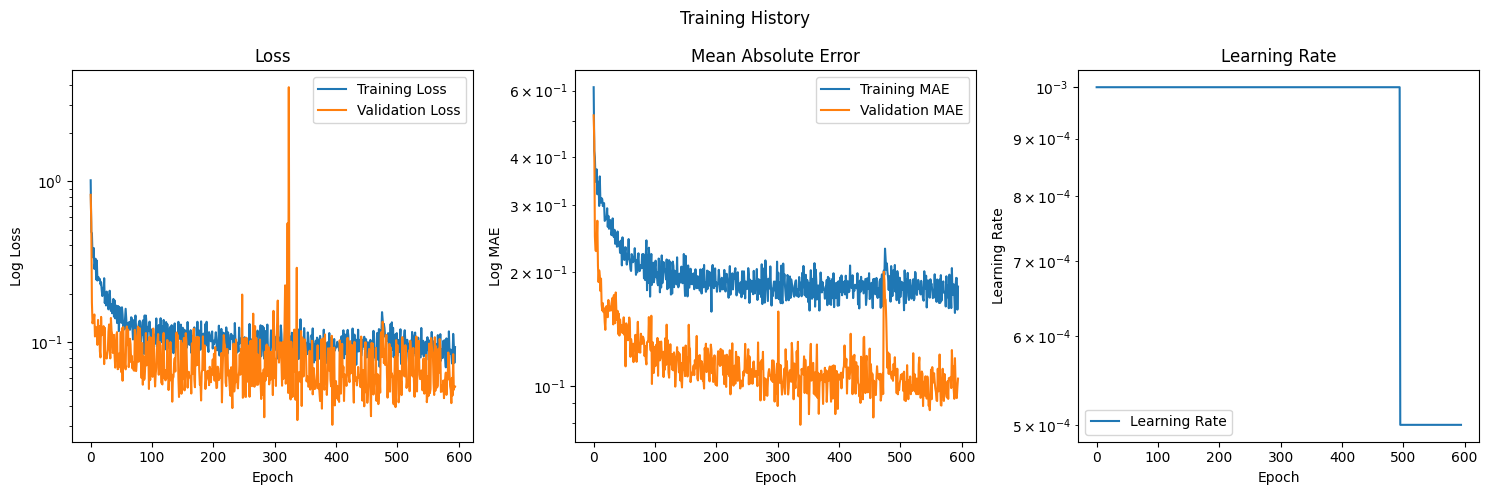


===== Results: BandRemoval:2 =====


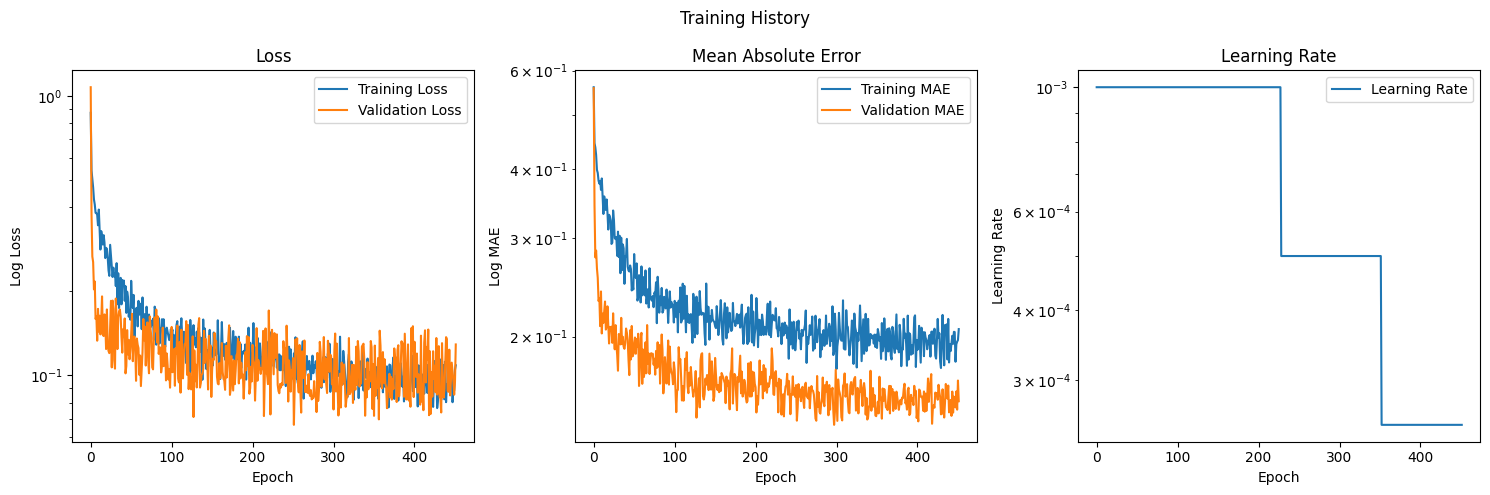


===== Results: SyntheticBanding =====


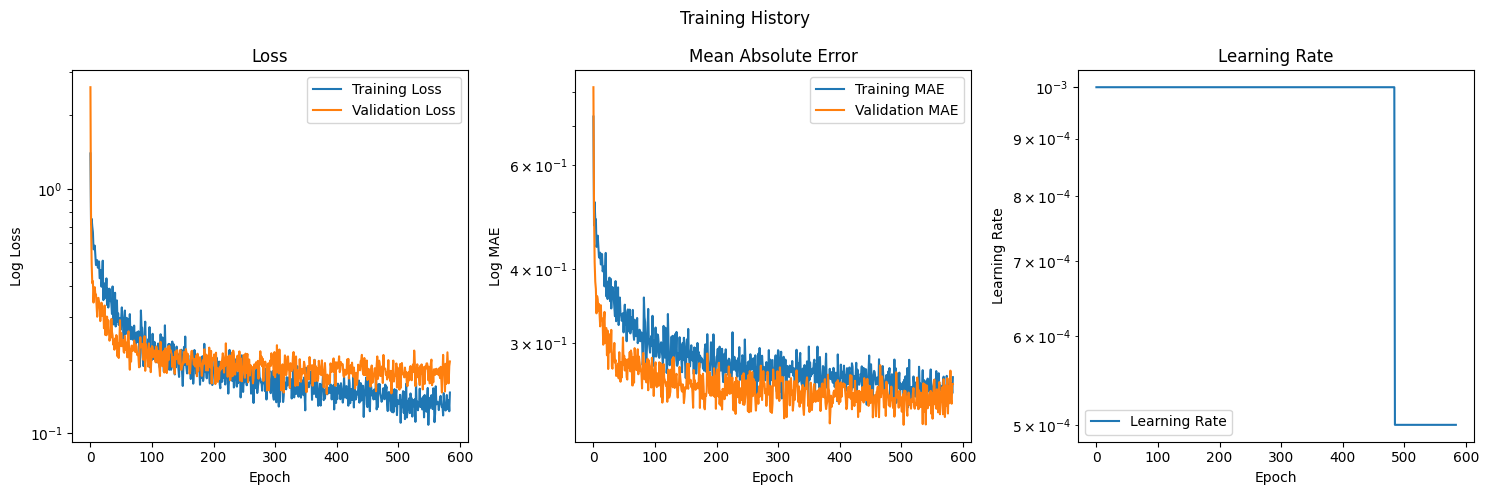


===== Results: SuperFOV =====


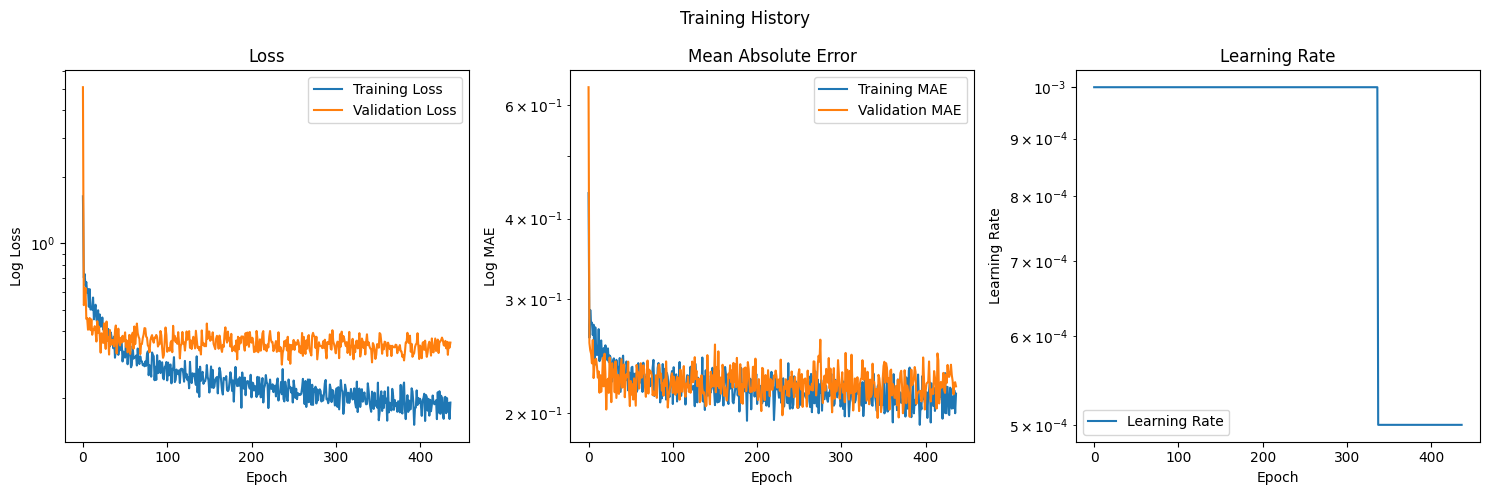


===== Results: SuperFOVi =====


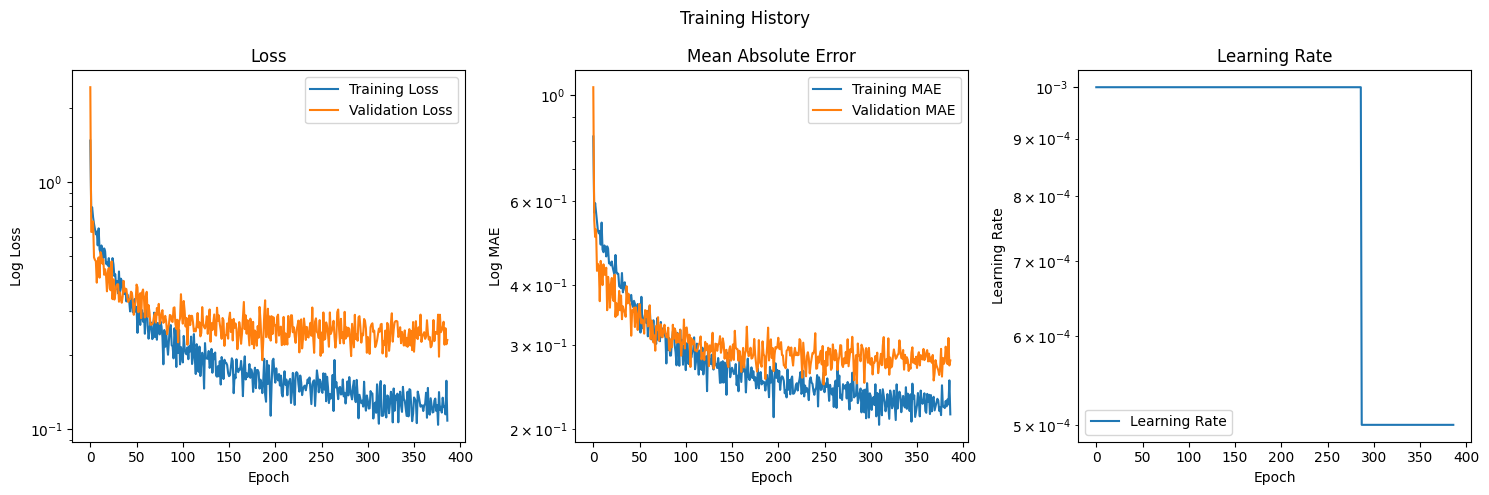

In [12]:
outputs = {}
for mode in modes:
    print(f"\n===== Results: {mode} =====")
    pass

    model_path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
    history_path = f"{model_path}_history.npz"
    if os.path.exists(history_path):
        history_data = np.load(history_path)
        history_dict = {}
        for key in history_data.files:
            history_dict[key] = history_data[key].tolist()
    else:
        history_dict = None
    
    deepssfp.plot_training_history(
        history_dict
    )